In [1]:
pip install pywavelets 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pywt
from PIL import Image

In [5]:
def message_to_binary(message):
    """Converts a text string into a string of binary digits."""
    binary_message = ""
    for char in message:
        binary_message += format(ord(char), "08b")
    binary_message += format(0, "08b")  # Hidden stop sign (null delimiter)
    return binary_message


def binary_to_message(binary_data):
    """Converts a string of binary digits back into text."""
    message = ""
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i : i + 8]
        if len(byte) < 8:
            break
        char_code = int(byte, 2)
        if char_code == 0:
            break
        message += chr(char_code)
    return message


def encode_dwt(image_path, secret_message, output_path, step=15):
    """Embeds data into the HH (diagonal noise) sub-band coefficients of the Red channel."""
    img = Image.open(image_path).convert("RGB")
    width, height = img.size

    # DWT cuts dimensions in half, so we force dimensions to be even numbers
    width = (width // 2) * 2
    height = (height // 2) * 2
    img = img.resize((width, height))

    img_array = np.array(img, dtype=float)

    # Separate the Red channel to hide data (leaving Green and Blue pristine)
    r_channel = img_array[:, :, 0]

    # 1. Apply DWT using the Haar wavelet
    # This splits the single Red channel into 4 matrices: LL, (LH, HL, HH)
    coeffs = pywt.dwt2(r_channel, "haar")
    LL, (LH, HL, HH) = coeffs

    binary_msg = message_to_binary(secret_message)
    msg_index = 0
    msg_len = len(binary_msg)

    # 2. Iterate through the HH (High-High) matrix to hide bits
    hh_height, hh_width = HH.shape
    for y in range(hh_height):
        for x in range(hh_width):
            if msg_index >= msg_len:
                break

            bit = int(binary_msg[msg_index])
            val = HH[y, x]

            # --- Quantization-based encoding ---
            # Moves the value to distinct mathematical 'zones' so it survives rounding
            if bit == 0:
                HH[y, x] = np.floor(val / step) * step + (step / 4)
            else:
                HH[y, x] = np.floor(val / step) * step + (3 * step / 4)

            msg_index += 1

        if msg_index >= msg_len:
            break

    if msg_index < msg_len:
        raise ValueError("Image is too small to hold this entire message!")

    # 3. Apply IDWT (Inverse DWT) to stitch the 4 sub-bands back into a normal channel
    r_channel_modified = pywt.idwt2((LL, (LH, HL, HH)), "haar")

    # Put the modified Red channel back into the original RGB array
    img_array[:, :, 0] = r_channel_modified

    # Clean up any math floats back into 0-255 integers and save as lossless PNG
    stego_img = Image.fromarray(np.uint8(np.clip(img_array, 0, 255)))
    stego_img.save(output_path, "PNG")
    print(f"Message hidden securely using DWT inside {output_path}!")


def decode_dwt(image_path, step=15):
    """Extracts data from the HH sub-band coefficients of the Red channel."""
    img = Image.open(image_path).convert("RGB")
    img_array = np.array(img, dtype=float)
    r_channel = img_array[:, :, 0]

    # Re-apply DWT to find the exact same frequency map
    coeffs = pywt.dwt2(r_channel, "haar")
    LL, (LH, HL, HH) = coeffs

    binary_data = ""
    hh_height, hh_width = HH.shape

    # Travel through the HH matrix just like the encoder did
    for y in range(hh_height):
        for x in range(hh_width):
            val = HH[y, x]

            # Read the position within the step range to deduce if it's a 0 or a 1
            remainder = val % step
            if remainder < (step / 2):
                binary_data += "0"
            else:
                binary_data += "1"

            # Check if we hit the 8-bit stop sign byte
            if len(binary_data) % 8 == 0:
                last_byte = binary_data[-8:]
                if int(last_byte, 2) == 0:
                    return binary_to_message(binary_data)

    return binary_to_message(binary_data)


# --- Example Usage ---
if __name__ == "__main__":
    # Hide the data
    encode_dwt(
        "input_image.jpg",
        "This data is hidden in Wavelet noise!",
        "dwt_encoded.png",
        step=20,
    )

    # Extract the data
    secret_text = decode_dwt("dwt_encoded.png", step=20)
    print(f"Decoded Message: {secret_text}")

Message hidden securely using DWT inside dwt_encoded.png!
Decoded Message: This data is hidden in Wavelet noise!


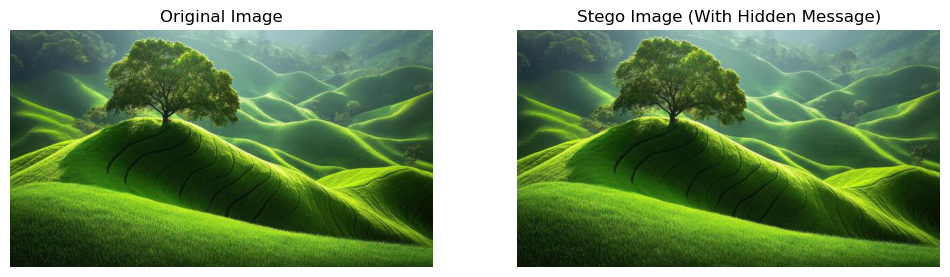

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# Load both images
original = Image.open("input_image.jpg")
stego = Image.open("dwt_encoded.png")

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(stego)
axes[1].set_title("Stego Image (With Hidden Message)")
axes[1].axis('off')

plt.show()